<a href="https://colab.research.google.com/github/psychic-coder/Credit-Card-Customer-Segmentation/blob/main/Credit_Card_Customer_Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings("ignore")

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [16]:
from google.colab import files
uploaded = files.upload()

# After upload, make sure the file name matches exactly.
# For this Kaggle dataset, the file is usually: CC GENERAL.csv
file_name = "CC GENERAL.csv"

Saving CC GENERAL.csv to CC GENERAL (2).csv


In [17]:
print("First 5 rows:")
display(df.head())

print("\nShape of dataset:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

First 5 rows:


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12



Shape of dataset: (8950, 17)

Column names:
['BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE']

Data types:
BALANCE                             float64
BALANCE_FREQUENCY                   float64
PURCHASES                           float64
ONEOFF_PURCHASES                    float64
INSTALLMENTS_PURCHASES              float64
CASH_ADVANCE                        float64
PURCHASES_FREQUENCY                 float64
ONEOFF_PURCHASES_FREQUENCY          float64
PURCHASES_INSTALLMENTS_FREQUENCY    float64
CASH_ADVANCE_FREQUENCY              float64
CASH_ADVANCE_TRX                      int64
PURCHASES_TRX                         int64
CREDIT_LIMIT                        float64
PAYMENTS                        

In [18]:
if "CUST_ID" in df.columns:
    df = df.drop("CUST_ID", axis=1)

print("\nShape after dropping ID column:", df.shape)


Shape after dropping ID column: (8950, 17)


In [19]:
imputer = SimpleImputer(strategy="median")
df_imputed = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)

print("\nMissing values after imputation:")
print(df_imputed.isnull().sum())



Missing values after imputation:
BALANCE                             0
BALANCE_FREQUENCY                   0
PURCHASES                           0
ONEOFF_PURCHASES                    0
INSTALLMENTS_PURCHASES              0
CASH_ADVANCE                        0
PURCHASES_FREQUENCY                 0
ONEOFF_PURCHASES_FREQUENCY          0
PURCHASES_INSTALLMENTS_FREQUENCY    0
CASH_ADVANCE_FREQUENCY              0
CASH_ADVANCE_TRX                    0
PURCHASES_TRX                       0
CREDIT_LIMIT                        0
PAYMENTS                            0
MINIMUM_PAYMENTS                    0
PRC_FULL_PAYMENT                    0
TENURE                              0
dtype: int64



Statistical summary:


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.282473,1733.143852,844.906767,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.646702,2895.063757,2332.792322,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,170.857654,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,788.713501,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


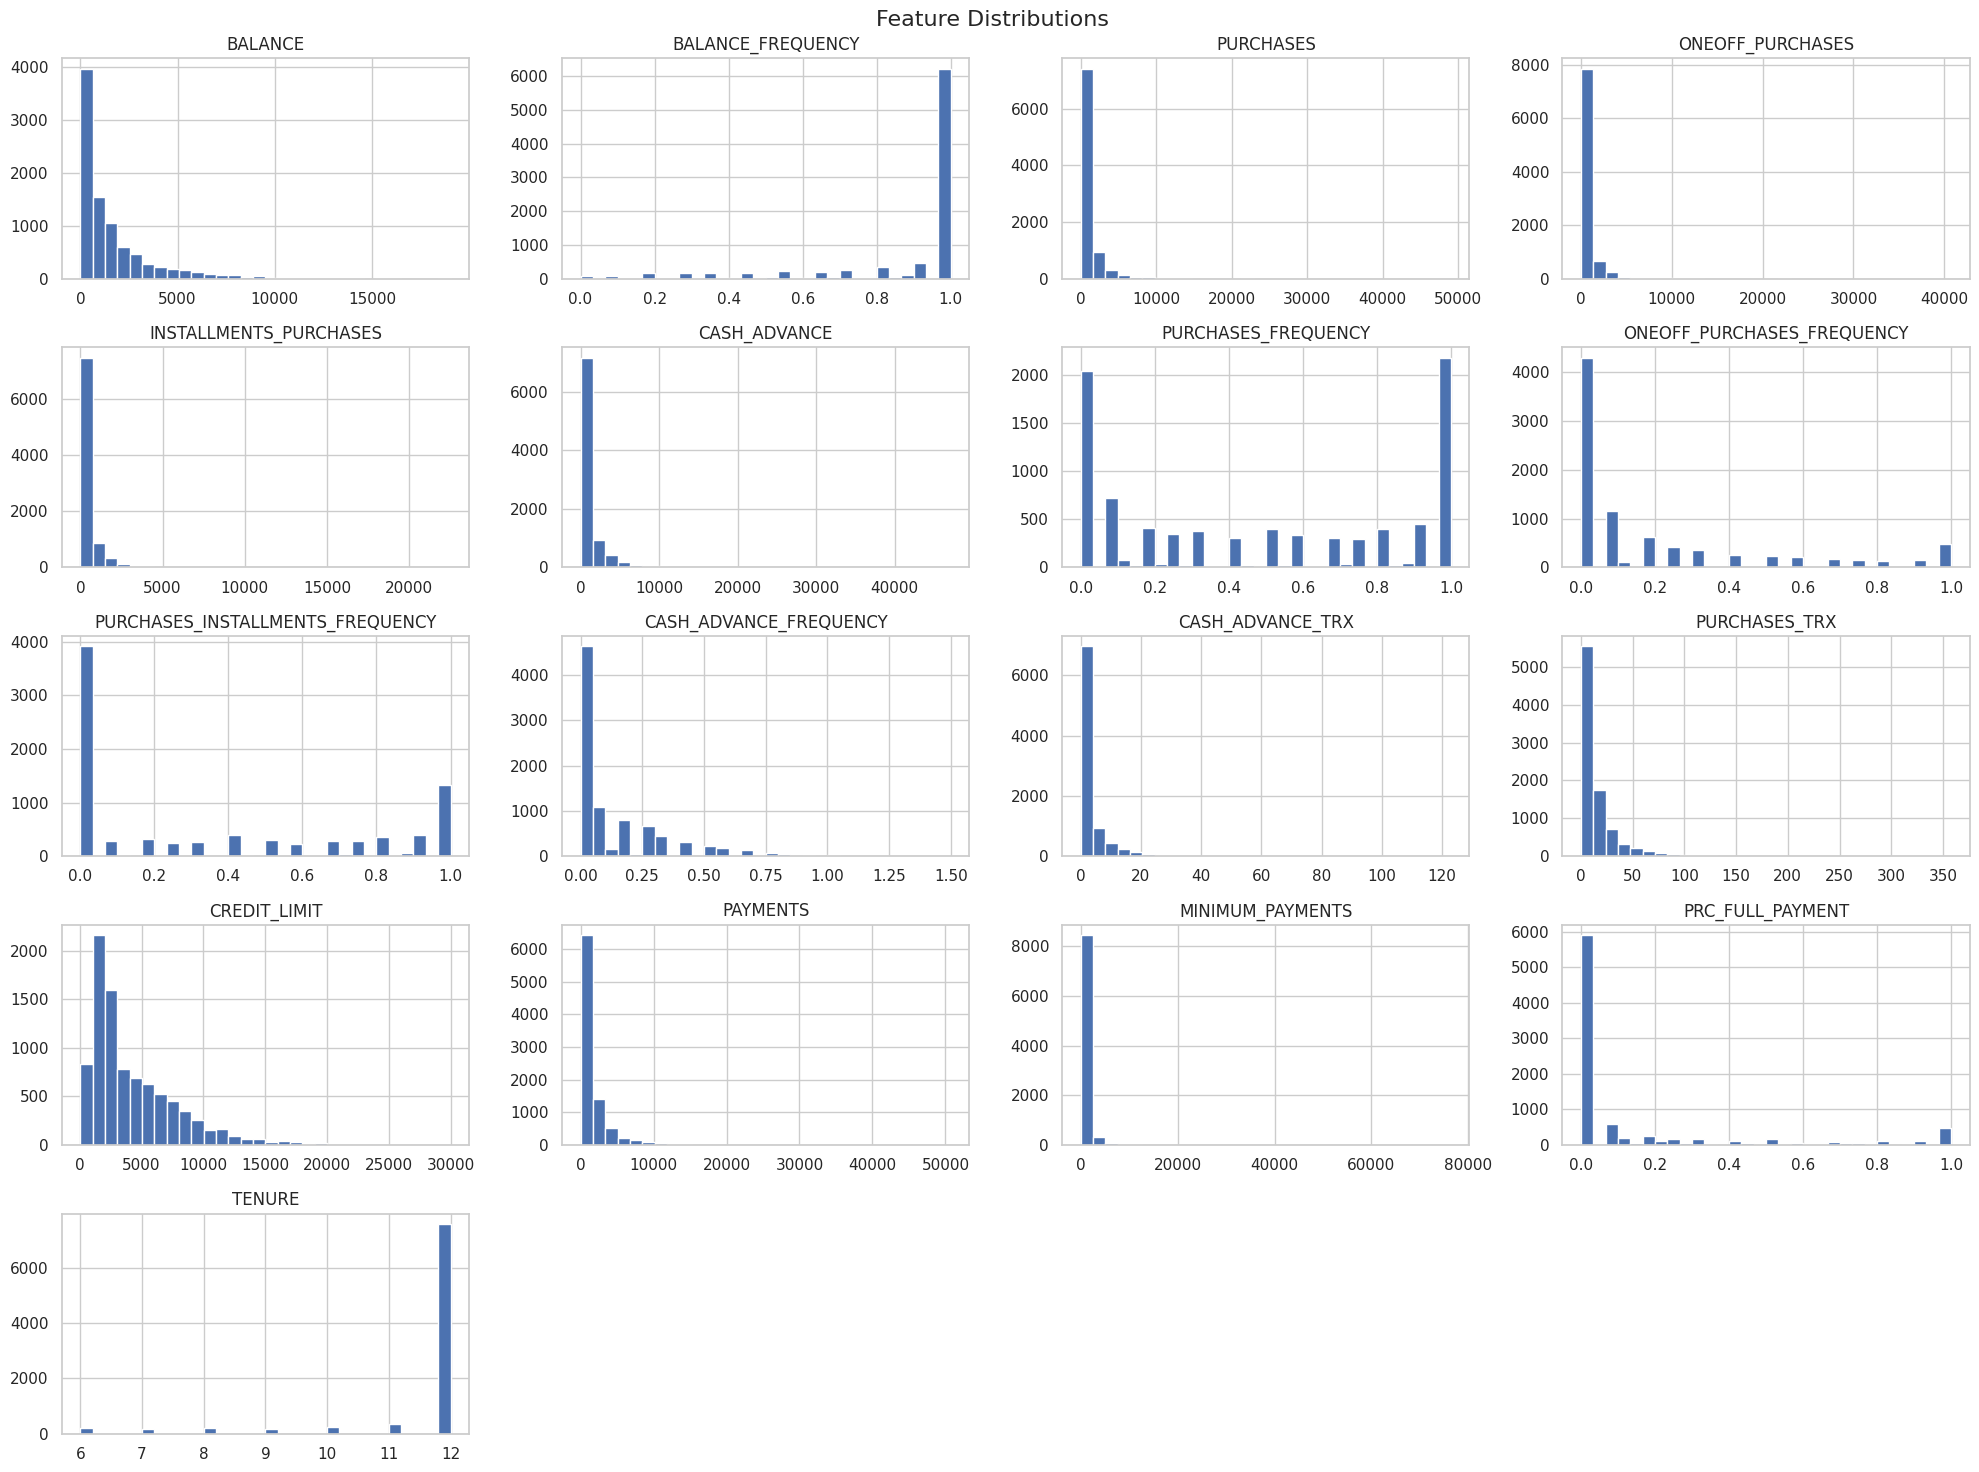

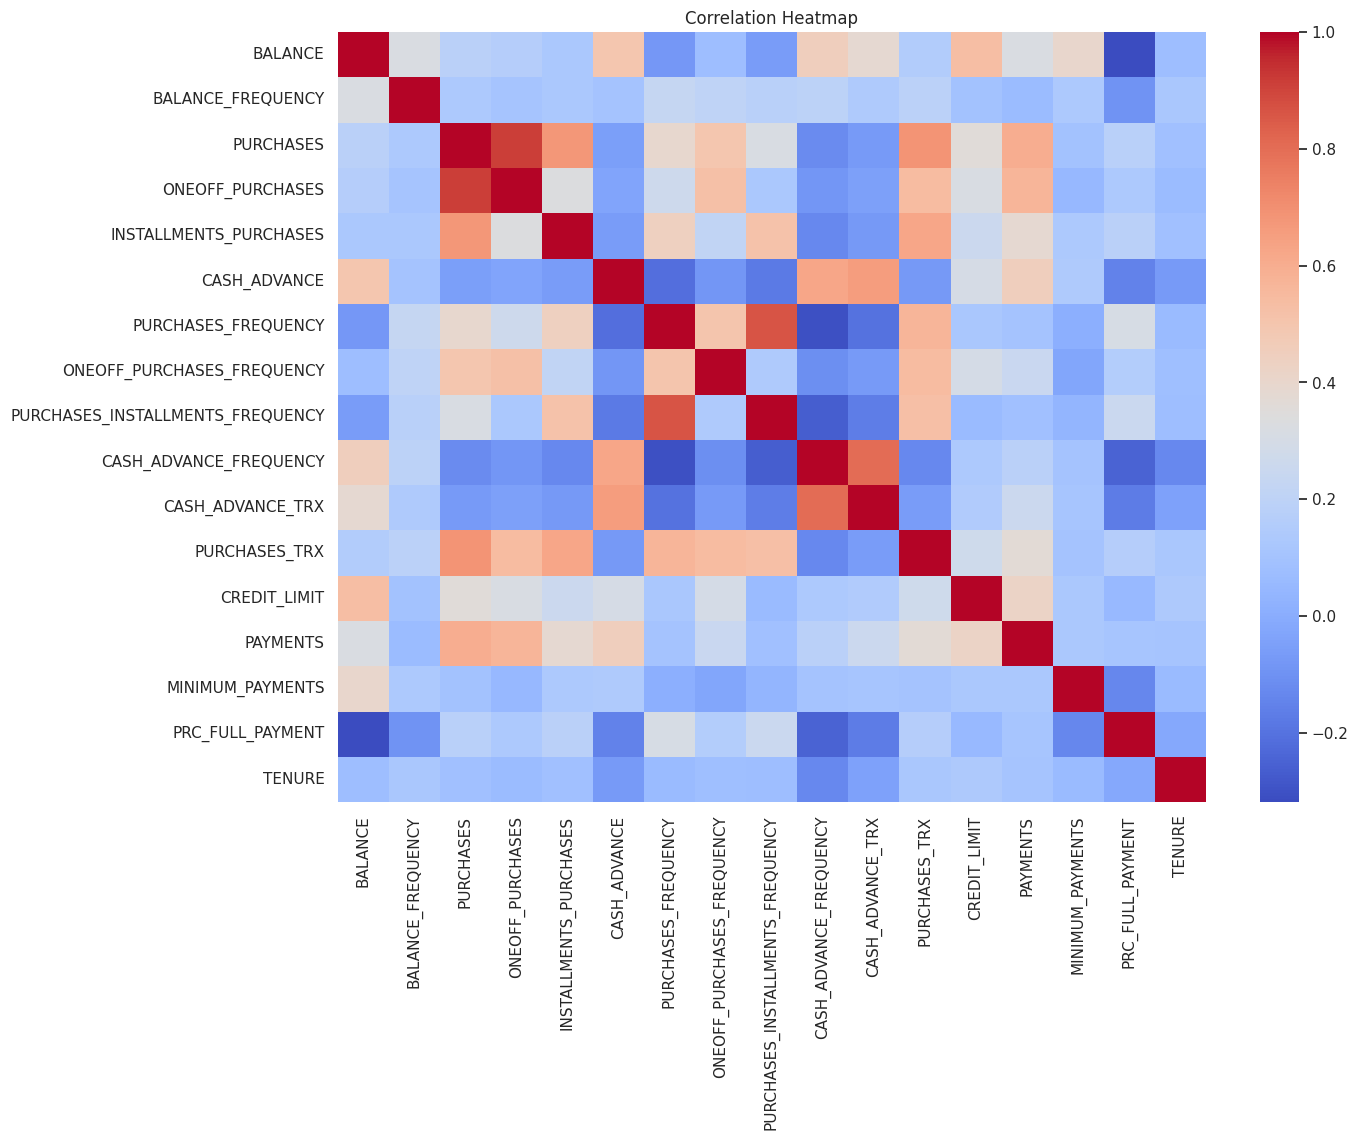

In [20]:
print("\nStatistical summary:")
display(df_imputed.describe())

# Histogram plots
df_imputed.hist(bins=30, figsize=(20, 15))
plt.suptitle("Feature Distributions", fontsize=16)
plt.tight_layout()
plt.show()

# Correlation heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(df_imputed.corr(), cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap")
plt.show()

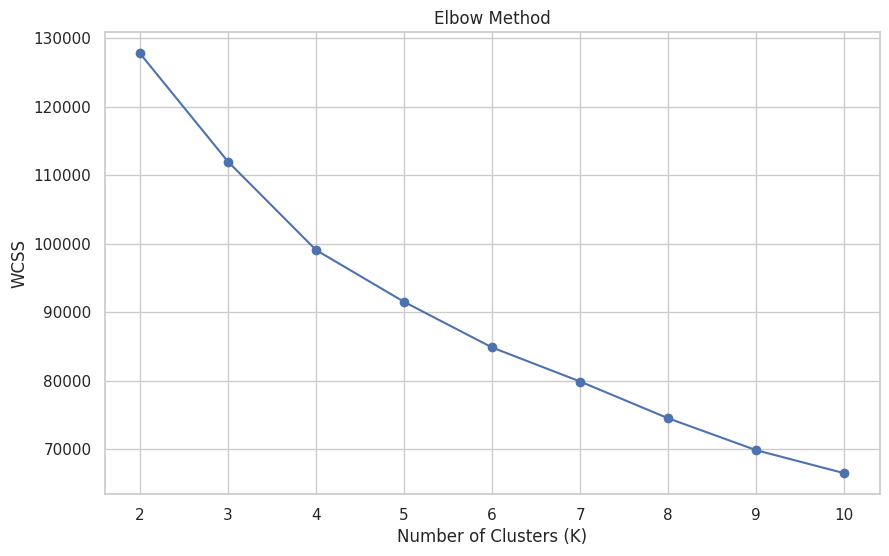

In [21]:
wcss = []

k_range = range(2, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

plt.plot(list(k_range), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.show()

K = 2, Silhouette Score = 0.2100
K = 3, Silhouette Score = 0.2510
K = 4, Silhouette Score = 0.1977
K = 5, Silhouette Score = 0.1931
K = 6, Silhouette Score = 0.2029
K = 7, Silhouette Score = 0.2077
K = 8, Silhouette Score = 0.2217
K = 9, Silhouette Score = 0.2260
K = 10, Silhouette Score = 0.2204


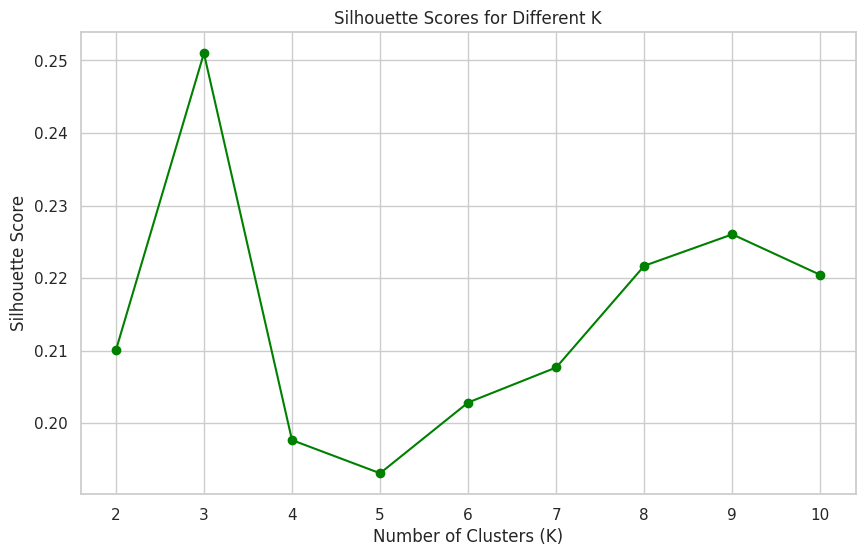

In [22]:
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(scaled_data)
    score = silhouette_score(scaled_data, labels)
    silhouette_scores.append(score)
    print(f"K = {k}, Silhouette Score = {score:.4f}")

plt.plot(list(k_range), silhouette_scores, marker='o', color='green')
plt.title("Silhouette Scores for Different K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.show()


In [23]:
optimal_k = 4

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(scaled_data)

df_result = df_imputed.copy()
df_result["Cluster"] = clusters

print("\nCluster counts:")
print(df_result["Cluster"].value_counts().sort_index())


Cluster counts:
Cluster
0    3977
1     409
2    1197
3    3367
Name: count, dtype: int64



Explained variance ratio by PCA components:
[0.27297671 0.2031378 ]


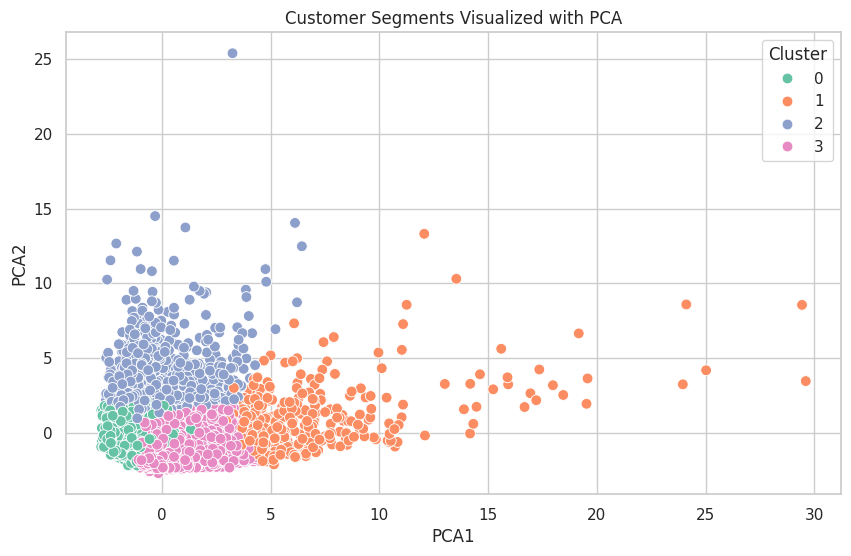

In [24]:
pca = PCA(n_components=2, random_state=42)
pca_components = pca.fit_transform(scaled_data)

df_result["PCA1"] = pca_components[:, 0]
df_result["PCA2"] = pca_components[:, 1]

print("\nExplained variance ratio by PCA components:")
print(pca.explained_variance_ratio_)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_result,
    x="PCA1",
    y="PCA2",
    hue="Cluster",
    palette="Set2",
    s=60
)
plt.title("Customer Segments Visualized with PCA")
plt.show()


Cluster Profile (Mean Feature Values):


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,PCA1,PCA2
Cluster,,,,,,,,,,,,,,,,,,,
0,1012.658327,0.789924,270.041785,209.937299,60.371441,596.509903,0.170145,0.086301,0.080558,0.114846,2.125471,2.903193,3278.640516,974.260054,553.900449,0.077981,11.446568,-1.341508,-0.190620
1,3551.153761,0.986879,7681.620098,5095.878826,2587.208264,653.638891,0.946418,0.739031,0.788060,0.071290,2.085575,89.359413,9696.943765,7288.739497,1972.767288,0.286707,11.951100,6.521057,0.740170
2,4602.449658,0.968389,501.862982,320.188797,181.759123,4521.509581,0.287832,0.138911,0.185671,0.484792,14.294904,7.665831,7546.160857,3484.054216,2003.674460,0.034888,11.386800,-0.465266,3.507808
3,894.907458,0.934734,1236.178934,593.974874,642.478274,210.570626,0.885165,0.297070,0.711842,0.042573,0.790021,22.091773,4213.207678,1332.194205,639.677258,0.269258,11.594595,0.957823,-1.111815


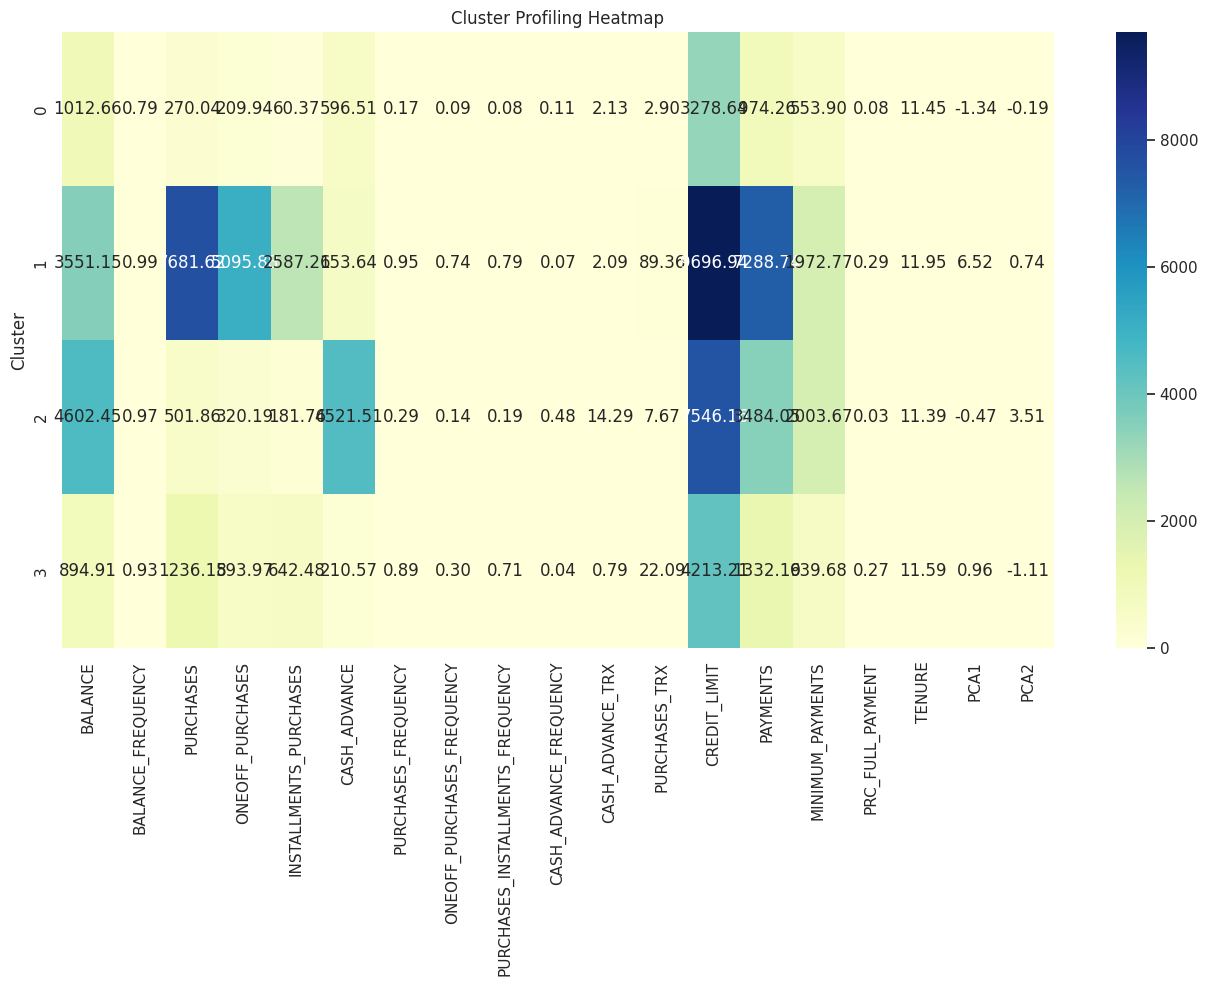

In [25]:
cluster_profile = df_result.groupby("Cluster").mean()
print("\nCluster Profile (Mean Feature Values):")
display(cluster_profile)

# Heatmap of cluster profile
plt.figure(figsize=(16, 8))
sns.heatmap(cluster_profile, annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Cluster Profiling Heatmap")
plt.show()

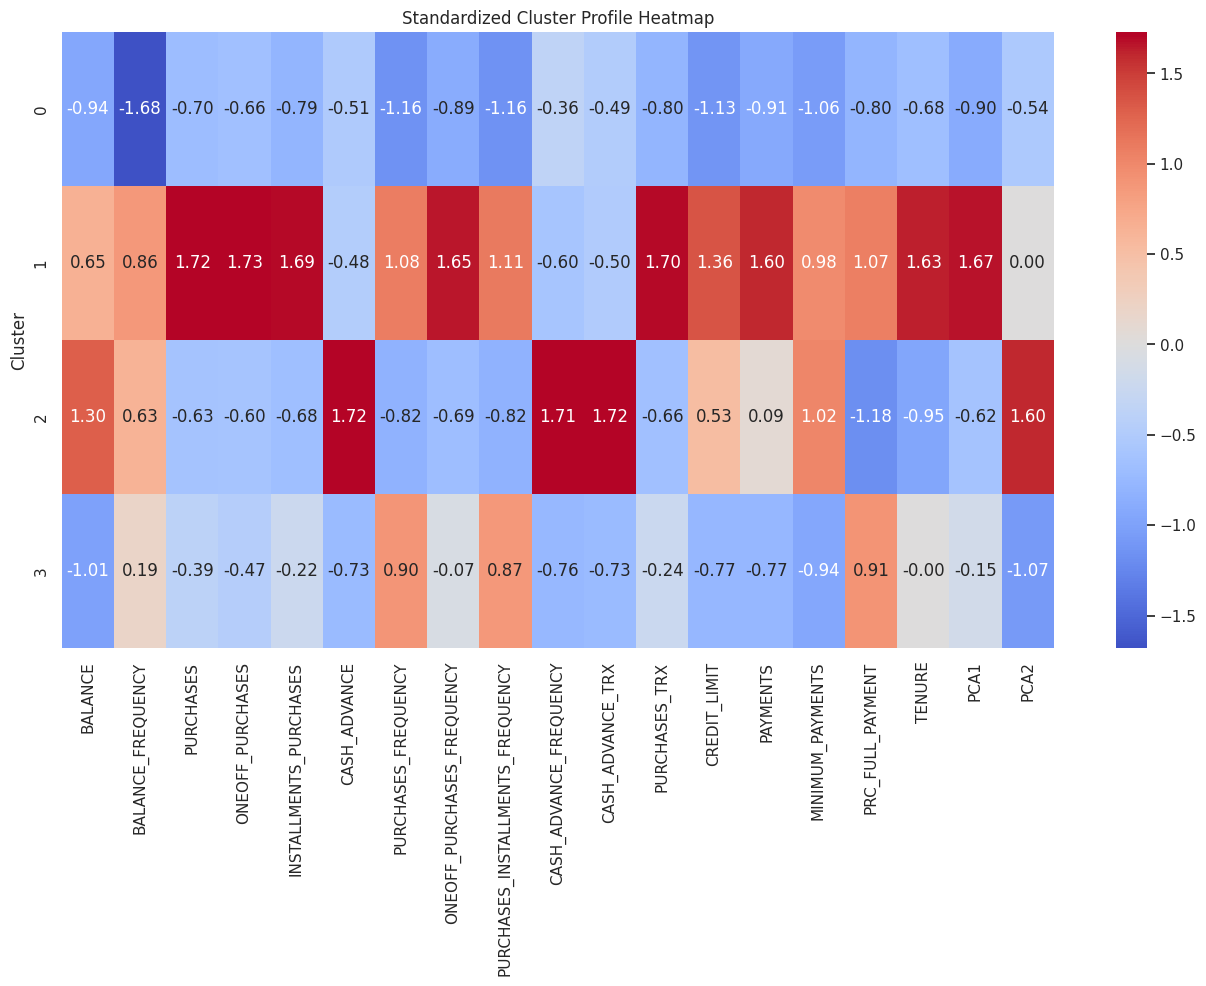

In [26]:
cluster_profile_scaled = pd.DataFrame(
    scaler.fit_transform(cluster_profile),
    columns=cluster_profile.columns,
    index=cluster_profile.index
)

plt.figure(figsize=(16, 8))
sns.heatmap(cluster_profile_scaled, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Standardized Cluster Profile Heatmap")
plt.show()


In [27]:
df_result.to_csv("credit_card_clustered_output.csv", index=False)
cluster_profile.to_csv("credit_card_cluster_profile.csv")

print("\nFiles saved successfully:")
print("1. credit_card_clustered_output.csv")
print("2. credit_card_cluster_profile.csv")





Files saved successfully:
1. credit_card_clustered_output.csv
2. credit_card_cluster_profile.csv


In [28]:
for cluster_id in sorted(df_result["Cluster"].unique()):
    print(f"\n--- Cluster {cluster_id} ---")
    print(cluster_profile.loc[cluster_id].sort_values(ascending=False).head(5))



--- Cluster 0 ---
CREDIT_LIMIT        3278.640516
BALANCE             1012.658327
PAYMENTS             974.260054
CASH_ADVANCE         596.509903
MINIMUM_PAYMENTS     553.900449
Name: 0, dtype: float64

--- Cluster 1 ---
CREDIT_LIMIT        9696.943765
PURCHASES           7681.620098
PAYMENTS            7288.739497
ONEOFF_PURCHASES    5095.878826
BALANCE             3551.153761
Name: 1, dtype: float64

--- Cluster 2 ---
CREDIT_LIMIT        7546.160857
BALANCE             4602.449658
CASH_ADVANCE        4521.509581
PAYMENTS            3484.054216
MINIMUM_PAYMENTS    2003.674460
Name: 2, dtype: float64

--- Cluster 3 ---
CREDIT_LIMIT              4213.207678
PAYMENTS                  1332.194205
PURCHASES                 1236.178934
BALANCE                    894.907458
INSTALLMENTS_PURCHASES     642.478274
Name: 3, dtype: float64


MODEL 2: DBSCAN CLUSTERING


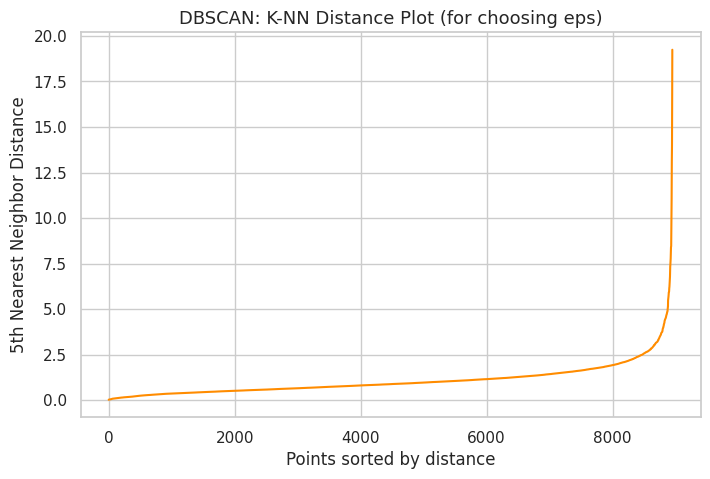


DBSCAN Results:
   Clusters Found  : 1
   Noise Points    : 138 (1.5%)
   Distribution    : {-1: 138, 0: 8812}
   ⚠️ Only 1 cluster found — try adjusting eps or min_samples


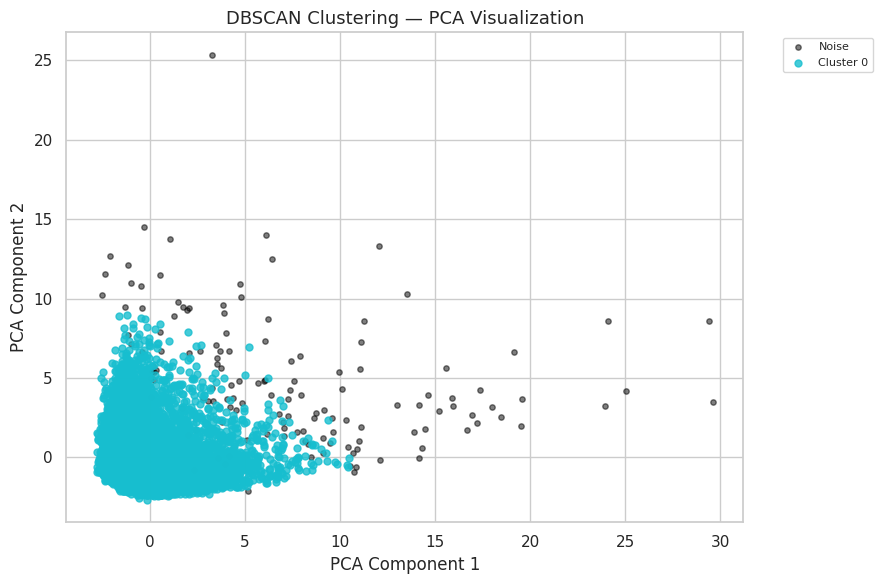

In [29]:

from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

print("=" * 50)
print("MODEL 2: DBSCAN CLUSTERING")
print("=" * 50)

# --- Step 1: K-NN Distance Plot to find optimal eps ---
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(scaled_data)
distances, indices = neighbors_fit.kneighbors(scaled_data)
distances = np.sort(distances[:, 4])  # 4th nearest neighbor distance

plt.figure(figsize=(8, 5))
plt.plot(distances, color='darkorange', linewidth=1.5)
plt.title("DBSCAN: K-NN Distance Plot (for choosing eps)", fontsize=13)
plt.xlabel("Points sorted by distance")
plt.ylabel("5th Nearest Neighbor Distance")
plt.grid(True)
plt.show()

# --- Step 2: Train DBSCAN ---
# Look at the "elbow" in the plot above and adjust eps accordingly
dbscan_model = DBSCAN(eps=3.5, min_samples=5)
dbscan_labels = dbscan_model.fit_predict(scaled_data)

n_clusters_dbscan = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)

print(f"\nDBSCAN Results:")
print(f"   Clusters Found  : {n_clusters_dbscan}")
print(f"   Noise Points    : {n_noise} ({n_noise/len(dbscan_labels)*100:.1f}%)")
print(f"   Distribution    : {pd.Series(dbscan_labels).value_counts().sort_index().to_dict()}")

# Silhouette & DB scores (only if >1 cluster)
if n_clusters_dbscan > 1:
    from sklearn.metrics import silhouette_score, davies_bouldin_score
    mask = dbscan_labels != -1
    dbscan_sil = silhouette_score(scaled_data[mask], dbscan_labels[mask])
    dbscan_db  = davies_bouldin_score(scaled_data[mask], dbscan_labels[mask])
    print(f"   Silhouette Score (excl. noise): {dbscan_sil:.4f}")
    print(f"   Davies-Bouldin Index          : {dbscan_db:.4f}")
else:
    dbscan_sil = None
    dbscan_db  = None
    print("   ⚠️ Only 1 cluster found — try adjusting eps or min_samples")

# --- Step 3: PCA Visualization ---
plt.figure(figsize=(9, 6))
unique_labels = sorted(set(dbscan_labels))
palette = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))
for lbl, col in zip(unique_labels, palette):
    mask_plot = dbscan_labels == lbl
    label_name = "Noise" if lbl == -1 else f"Cluster {lbl}"
    color = "black" if lbl == -1 else col
    plt.scatter(pca_components[mask_plot, 0], pca_components[mask_plot, 1],
                c=[color], s=15 if lbl == -1 else 25,
                alpha=0.5 if lbl == -1 else 0.8, label=label_name)
plt.title("DBSCAN Clustering — PCA Visualization", fontsize=13)
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

MODEL 3: HIERARCHICAL (AGGLOMERATIVE) CLUSTERING


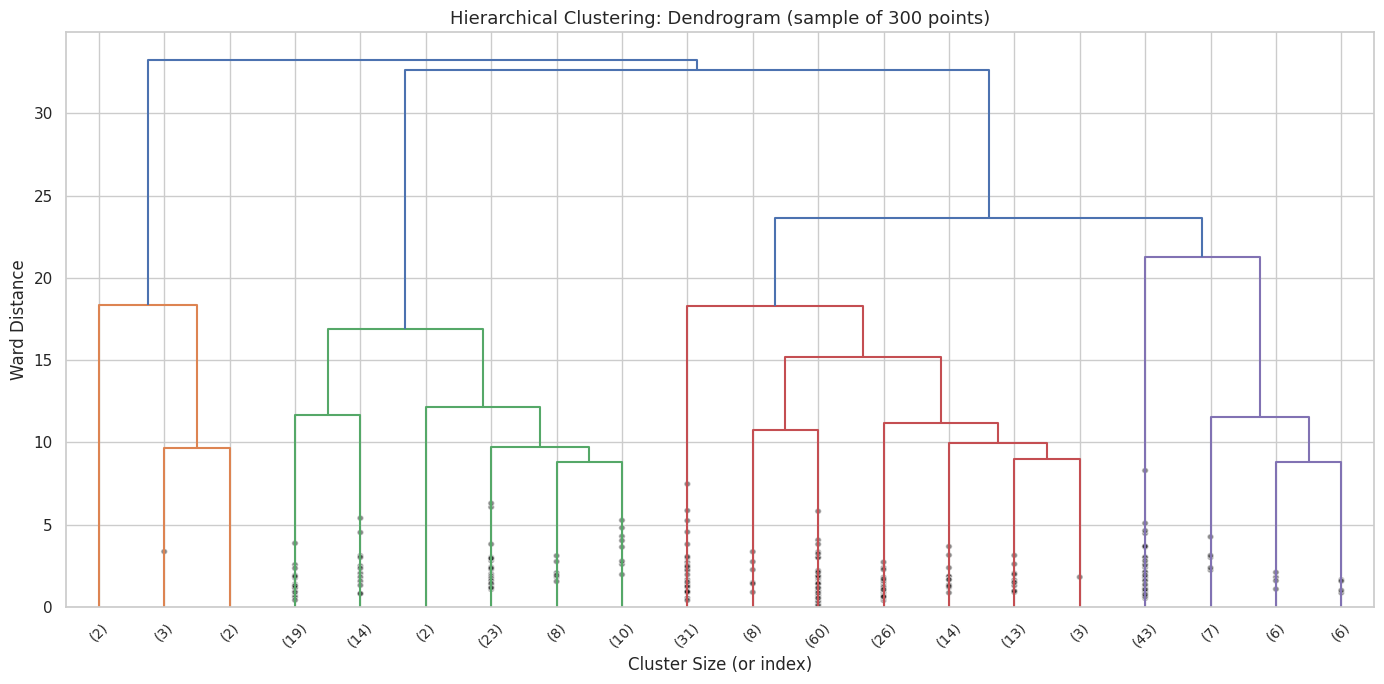


✅ Hierarchical Clustering (n_clusters=4, linkage=ward)
   Silhouette Score    : 0.1598
   Davies-Bouldin Index: 1.7503
   Distribution: {0: 4875, 1: 300, 2: 1194, 3: 2581}


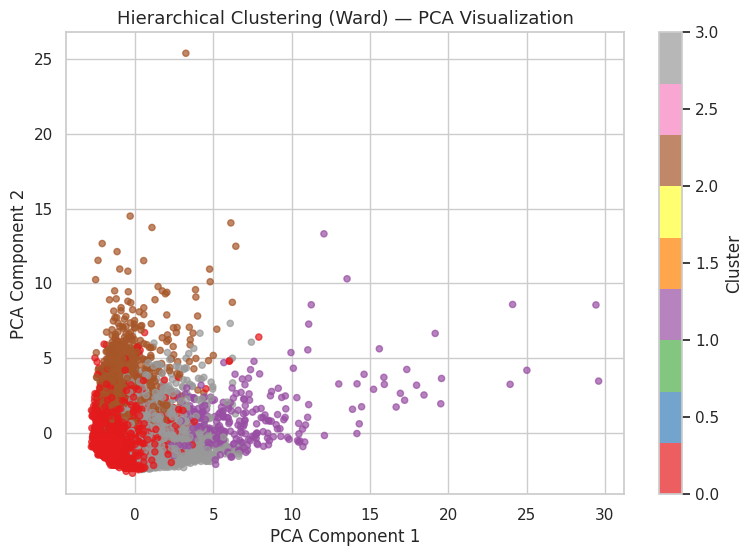

In [30]:


from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.metrics import silhouette_score, davies_bouldin_score

print("=" * 50)
print("MODEL 3: HIERARCHICAL (AGGLOMERATIVE) CLUSTERING")
print("=" * 50)

# --- Step 1: Dendrogram on a sample (full 8950 is too large to display) ---
sample_idx = np.random.choice(len(scaled_data), size=300, replace=False)
sample_data = scaled_data[sample_idx]

linked = linkage(sample_data, method="ward")

plt.figure(figsize=(14, 7))
dendrogram(linked,
           truncate_mode="lastp",
           p=20,
           leaf_rotation=45,
           leaf_font_size=10,
           show_contracted=True)
plt.title("Hierarchical Clustering: Dendrogram (sample of 300 points)", fontsize=13)
plt.xlabel("Cluster Size (or index)")
plt.ylabel("Ward Distance")
plt.tight_layout()
plt.show()

# --- Step 2: Train Agglomerative Clustering ---
hc_model = AgglomerativeClustering(n_clusters=4, linkage="ward")
hc_labels = hc_model.fit_predict(scaled_data)

hc_sil = silhouette_score(scaled_data, hc_labels)
hc_db  = davies_bouldin_score(scaled_data, hc_labels)

print(f"\n✅ Hierarchical Clustering (n_clusters=4, linkage=ward)")
print(f"   Silhouette Score    : {hc_sil:.4f}")
print(f"   Davies-Bouldin Index: {hc_db:.4f}")
print(f"   Distribution: {pd.Series(hc_labels).value_counts().sort_index().to_dict()}")

# --- Step 3: PCA Visualization ---
plt.figure(figsize=(9, 6))
scatter = plt.scatter(pca_components[:, 0], pca_components[:, 1],
                      c=hc_labels, cmap="Set1", s=20, alpha=0.7)
plt.colorbar(scatter, label="Cluster")
plt.title("Hierarchical Clustering (Ward) — PCA Visualization", fontsize=13)
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()

In [31]:


print("=" * 60)
print("MODEL COMPARISON SUMMARY")
print("=" * 60)

# Retrieve K-Means scores from existing variables
from sklearn.metrics import silhouette_score, davies_bouldin_score
kmeans_sil = silhouette_score(scaled_data, clusters)
kmeans_db  = davies_bouldin_score(scaled_data, clusters)

comparison_data = {
    "Model": ["K-Means", "DBSCAN", "Hierarchical (Ward)"],
    "Clusters Found": [
        len(set(clusters)),
        n_clusters_dbscan,
        4
    ],
    "Silhouette Score ↑": [
        round(kmeans_sil, 4),
        round(dbscan_sil, 4) if dbscan_sil is not None else "N/A",
        round(hc_sil, 4)
    ],
    "Davies-Bouldin ↓": [
        round(kmeans_db, 4),
        round(dbscan_db, 4) if dbscan_db is not None else "N/A",
        round(hc_db, 4)
    ],
    "Handles Noise": ["No", "Yes (labels as -1)", "No"],
    "Needs K upfront": ["Yes", "No", "Yes"],
    "Scalability": ["High", "Medium", "Low"],
}

df_comparison = pd.DataFrame(comparison_data)
display(df_comparison)

df_comparison.to_csv("model_comparison.csv", index=False)
print("\n✅ model_comparison.csv saved!")

MODEL COMPARISON SUMMARY


,Model,Clusters Found,Silhouette Score ↑,Davies-Bouldin ↓,Handles Noise,Needs K upfront,Scalability
0,K-Means,4,0.1977,1.5748,No,Yes,High
1,DBSCAN,1,N/A,N/A,Yes (labels as -1),No,Medium
2,Hierarchical (Ward),4,0.1598,1.7503,No,Yes,Low



✅ model_comparison.csv saved!
